# 3. Рекуррентные нейросети

## 1. Используемые библиотеки

In [ ]:
import numpy as np
import pandas as pd
import time
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr



## 2. Загрузка и просмотр датасета


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Bike_sharing/hour.csv', sep=',')

print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов')
print('\n--- Первые 5 строк ---')
display(df.head())

print('\n--- Типы данных и наличие значений ---')
print(df.info())

Размер датасета: 17379 строк, 17 столбцов

--- Первые 5 строк ---


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1



--- Типы данных и наличие значений ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB
None


## 3. Подготовка датасета

*   Очистка не требуется, так как в датасете нет пропусков или дубликатов
*   Определяем целевую переменную и признаки для модели

In [ ]:
# Целевая переменная
target = 'cnt'

# Признаки для модели (убираем instant, dteday, casual, registered)
features = ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
            'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']

df_model = df[features + [target]].copy()

## 4. Циклически кодируем время

In [ ]:
def encode_cyclical(df, column, max_val):
    """Кодируем циклический признак через sin/cos"""
    df[f'{column}_sin'] = np.sin(2 * np.pi * df[column] / max_val)
    df[f'{column}_cos'] = np.cos(2 * np.pi * df[column] / max_val)
    return df

# Применяем к временным признакам
df_model = encode_cyclical(df_model, 'hr', 24)
df_model = encode_cyclical(df_model, 'mnth', 12)
df_model = encode_cyclical(df_model, 'weekday', 7)

# Удаляем исходные циклические столбцы
df_model = df_model.drop(columns=['hr', 'mnth', 'weekday'])

## 5. Нормализация данных

RNN чувствительны к масштабу — нормализуем всё в диапазон [0, 1]

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df_model)

# Сохраняем индексы для обратного преобразования прогнозов
target_idx = list(df_model.columns).index(target)

## Создание последовательностей (time steps)

In [ ]:
def create_sequences(data, target_idx, time_steps=24):

    X, y = [], []
    for i in range(time_steps, len(data)):
        X.append(data[i-time_steps:i])
        y.append(data[i, target_idx])
    return np.array(X), np.array(y)

TIME_STEPS = 24  # Используем последние 24 часа для прогноза
X, y = create_sequences(scaled_data, target_idx, TIME_STEPS)

print(f"Форма X: {X.shape}")  # (samples, time_steps, features)
print(f"Форма y: {y.shape}")  # (samples,)

Форма X: (17355, 24, 16)
Форма y: (17355,)


## Разделение на обучающую и тестовую выборку

In [ ]:
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Train: {X_train.shape[0]} samples, Test: {X_test.shape[0]} samples")

Train: 13884 samples, Test: 3471 samples


# RNN

## Построение модель

In [ ]:
# Параметры модели
INPUT_DIM = X_train.shape[2]  # Количество признаков
TIME_STEPS = X_train.shape[1] # Длина последовательности

model_rnn = Sequential([
    SimpleRNN(64, activation='relu', input_shape=(TIME_STEPS, INPUT_DIM)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)  # Прогнозируем одно значение: cnt
])

model_rnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model_rnn.summary()

NameError: name 'X_train' is not defined

## Обучение модели

In [ ]:
history_rnn = model_rnn.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    verbose=1,
    callbacks=[
        # EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    ]
)

Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0241 - mae: 0.1114 - val_loss: 0.0189 - val_mae: 0.1065
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0098 - mae: 0.0725 - val_loss: 0.0146 - val_mae: 0.0956
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0071 - mae: 0.0613 - val_loss: 0.0125 - val_mae: 0.0886
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0054 - mae: 0.0533 - val_loss: 0.0081 - val_mae: 0.0717
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0044 - mae: 0.0478 - val_loss: 0.0073 - val_mae: 0.0658
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0037 - mae: 0.0442 - val_loss: 0.0058 - val_mae: 0.0578
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0032 - mae: 0.0408 - val_loss: 0.0047 - val_mae: 0.0508
Epoch 8/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0030 - mae: 0.0394 - val_loss: 0.0040 - val_mae: 0.0481
Epoch 9/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - 

## Оценка результатов

In [ ]:
def inverse_transform_target(y_true, y_pred, scaler, target_idx, n_features):
    # обратное преобразование только для целевой переменной
    # Создаём матрицы нулей
    y_true_matrix = np.zeros((len(y_true), n_features))
    y_pred_matrix = np.zeros((len(y_pred), n_features))

    # Заполняем только целевой столбец
    y_true_matrix[:, target_idx] = y_true
    y_pred_matrix[:, target_idx] = y_pred

    # Обратное преобразование
    y_true_inv = scaler.inverse_transform(y_true_matrix)[:, target_idx]
    y_pred_inv = scaler.inverse_transform(y_pred_matrix)[:, target_idx]

    return y_true_inv, y_pred_inv


=== МЕТРИКИ НА ТЕСТОВОЙ ВЫБОРКЕ ===
Метрика         Train                Test                
-------------------------------------------------------
MAE             26.05                44.87               
RMSE            39.13                67.23               
R² Score        0.9451               0.9071              

Корреляция Пирсона между прогнозом и фактом: 0.9750 (p=0.000000)


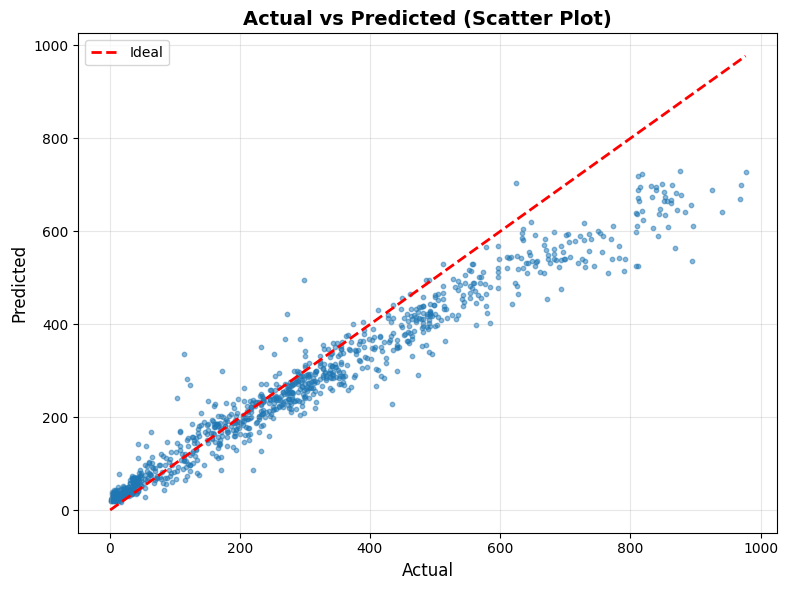

In [ ]:


# Прогнозы
y_pred_train = model_rnn.predict(X_train, verbose=0).flatten()
y_pred_test = model_rnn.predict(X_test, verbose=0).flatten()

# Обратное преобразование
n_features = scaled_data.shape[1]
y_train_inv, y_pred_train_inv = inverse_transform_target(
    y_train, y_pred_train, scaler, target_idx, n_features
)
y_test_inv, y_pred_test_inv = inverse_transform_target(
    y_test, y_pred_test, scaler, target_idx, n_features
)

# Метрики
train_mae = mean_absolute_error(y_train_inv, y_pred_train_inv)
train_rmse = np.sqrt(mean_squared_error(y_train_inv, y_pred_train_inv))
train_r2 = r2_score(y_train_inv, y_pred_train_inv)

test_mae = mean_absolute_error(y_test_inv, y_pred_test_inv)
test_rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_test_inv))
test_r2 = r2_score(y_test_inv, y_pred_test_inv)

print("\n=== МЕТРИКИ НА ТЕСТОВОЙ ВЫБОРКЕ ===")
print(f"{'Метрика':<15} {'Train':<20} {'Test':<20}")
print("-" * 55)
print(f"{'MAE':<15} {train_mae:<20.2f} {test_mae:<20.2f}")
print(f"{'RMSE':<15} {train_rmse:<20.2f} {test_rmse:<20.2f}")
print(f"{'R² Score':<15} {train_r2:<20.4f} {test_r2:<20.4f}")

# 2. Проверка корреляции между прогнозом и фактом
corr, p_value = pearsonr(y_test_inv, y_pred_test_inv)
print(f"\nКорреляция Пирсона между прогнозом и фактом: {corr:.4f} (p={p_value:.6f})")

# 3. Визуализация scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test_inv[:1000], y_pred_test_inv[:1000], alpha=0.5, s=10)
plt.plot([y_test_inv.min(), y_test_inv.max()],
         [y_test_inv.min(), y_test_inv.max()],
         'r--', linewidth=2, label='Ideal')
plt.xlabel('Actual', fontsize=12)
plt.ylabel('Predicted', fontsize=12)
plt.title('Actual vs Predicted (Scatter Plot)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Визуализация результатов

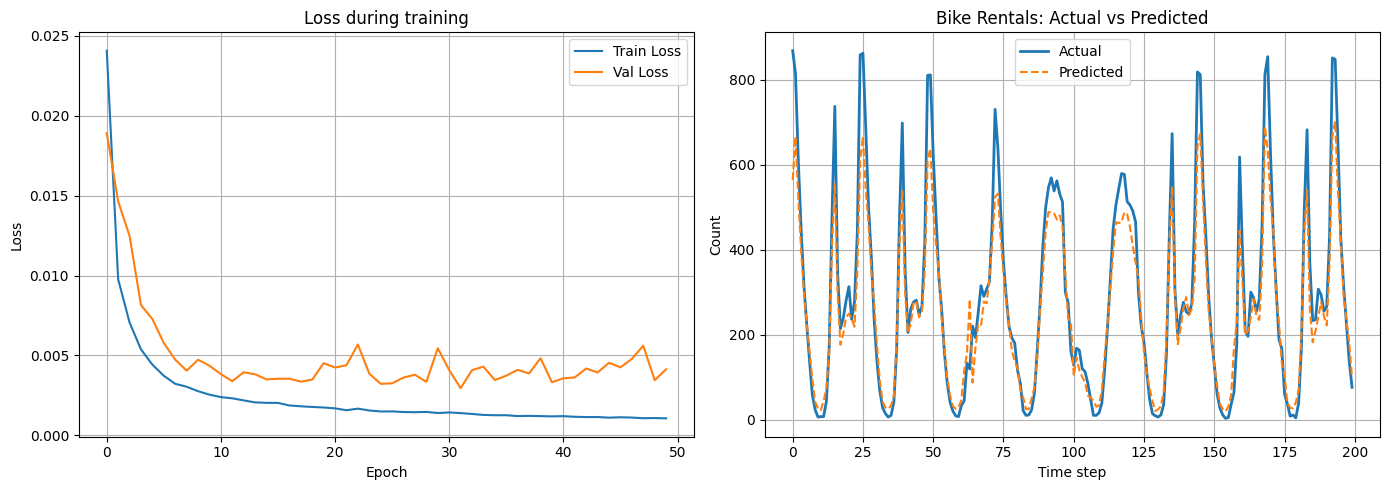

In [ ]:
plt.figure(figsize=(14, 5))

# График потерь
plt.subplot(1, 2, 1)
plt.plot(history_rnn.history['loss'], label='Train Loss')
plt.plot(history_rnn.history['val_loss'], label='Val Loss')
plt.title('Loss during training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Прогноз vs Факт
plt.subplot(1, 2, 2)
sample_size = 200
plt.plot(y_test_inv[:sample_size], label='Actual', linewidth=2)
plt.plot(y_pred_test_inv[:sample_size], label='Predicted', linestyle='--')
plt.title('Bike Rentals: Actual vs Predicted')
plt.xlabel('Time step')
plt.ylabel('Count')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# LSTM

## tensorflow

In [ ]:
def build_tf_lstm(input_shape, hidden_units=64):
    model = tf.keras.Sequential([
        tf.keras.layers.LSTM(hidden_units, activation='tanh',
                             return_sequences=False, input_shape=input_shape),
        tf.keras.layers.Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='mse', metrics=['mae'])
    return model

# Обучение TF модели
def train_tf_model(X_tr, y_tr, X_te, y_te, epochs=50, batch_size=32):
    print("Обучение TensorFlow LSTM...")
    model = build_tf_lstm(input_shape=(X_tr.shape[1], X_tr.shape[2]))
    history = model.fit(X_tr, y_tr, epochs=epochs, batch_size=batch_size,
                        validation_data=(X_te, y_te), verbose=1)

    # Оценка
    y_pred = model.predict(X_te).flatten()
    mse = mean_squared_error(y_te, y_pred)
    mae = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mse)
    print(f"TF LSTM | MSE: {mse:.2f} | RMSE: {rmse:.2f} | MAE: {mae:.2f}")
    return model, history, y_pred, {"MSE": mse, "RMSE": rmse, "MAE": mae}

## Запуск TF

In [ ]:
def evaluate_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    return {"MSE": mse, "RMSE": rmse, "MAE": mae}

tf_model, tf_history, tf_pred, tf_metrics = train_tf_model(X_train, y_train, X_test, y_test, epochs=50, batch_size=32)

Обучение TensorFlow LSTM...
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


434/434 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 0.0115 - mae: 0.0741 - val_loss: 0.0177 - val_mae: 0.0897
Epoch 2/50
434/434 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0056 - mae: 0.0525 - val_loss: 0.0090 - val_mae: 0.0657
Epoch 3/50
434/434 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0030 - mae: 0.0379 - val_loss: 0.0046 - val_mae: 0.0460
Epoch 4/50
434/434 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.0021 - mae: 0.0316 - val_loss: 0.0044 - val_mae: 0.0458
Epoch 5/50
434/434 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0019 - mae: 0.0298 - val_loss: 0.0036 - val_mae: 0.0400
Epoch 6/50
434/434 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 0.0016 - mae: 0.0276 - val_loss: 0.0031 - val_mae: 0.0387
Epoch 7/50
434/434 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0016 - mae: 0.0276 - val_loss: 0.0029 - val_mae: 0.0375
Epoch 8/50
434/434 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0016 - mae: 0.0271 - val_loss: 0.0034 - val_mae: 0.0402
Epoch 9/50
434/434 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - lo

## Оценка и визуализация

In [ ]:
def evaluate_and_plot(y_true, y_pred, y_true_inv, y_pred_inv,
                      model_name="Model", history=None, sample_size=200):
    print(f"\n{'='*20} {model_name.upper()} {'='*20}")

    # === МЕТРИКИ ===
    train_mae = mean_absolute_error(y_true_inv, y_pred_inv)
    train_rmse = np.sqrt(mean_squared_error(y_true_inv, y_pred_inv))
    train_r2 = r2_score(y_true_inv, y_pred_inv)

    print(f"\n=== МЕТРИКИ (обратное преобразование) ===")
    print(f"{'Метрика':<15} {'Значение':<20}")
    print("-" * 35)
    print(f"{'MAE':<15} {train_mae:<20.2f}")
    print(f"{'RMSE':<15} {train_rmse:<20.2f}")
    print(f"{'R² Score':<15} {train_r2:<20.4f}")

    # === КОРРЕЛЯЦИЯ ===
    corr, p_value = pearsonr(y_true_inv, y_pred_inv)
    print(f"\nКорреляция Пирсона: {corr:.4f} (p={p_value:.6f})")

    # === ГРАФИКИ ===
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Scatter plot
    axes[0].scatter(y_true_inv[:1000], y_pred_inv[:1000], alpha=0.5, s=10, color='steelblue')
    axes[0].plot([y_true_inv.min(), y_true_inv.max()],
                 [y_true_inv.min(), y_true_inv.max()],
                 'r--', linewidth=2, label='Ideal')
    axes[0].set_xlabel('Actual', fontsize=11)
    axes[0].set_ylabel('Predicted', fontsize=11)
    axes[0].set_title(f'{model_name}: Actual vs Predicted', fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Time series plot
    axes[1].plot(y_true_inv[:sample_size], label='Actual', linewidth=2, color='navy')
    axes[1].plot(y_pred_inv[:sample_size], label='Predicted', linestyle='--', color='orange')
    axes[1].set_xlabel('Time step', fontsize=11)
    axes[1].set_ylabel('Bike Count', fontsize=11)
    axes[1].set_title(f'{model_name}: Forecast (first {sample_size} samples)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    if history is not None:
        hist_data = history.history if hasattr(history, 'history') else history

        plt.figure(figsize=(6, 4))
        plt.plot(hist_data['loss'], label='Train Loss')
        if 'val_loss' in hist_data:
            plt.plot(hist_data['val_loss'], label='Val Loss')
        plt.title(f'{model_name}: Training Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    return {"MAE": train_mae, "RMSE": train_rmse, "R2": train_r2, "Pearson": corr}

## Оценка библиотечной


==================== TENSORFLOW LSTM ====================

=== МЕТРИКИ (обратное преобразование) ===
Метрика         Значение            
-----------------------------------
MAE             29.60               
RMSE            43.16               
R² Score        0.9617              

Корреляция Пирсона: 0.9817 (p=0.000000)


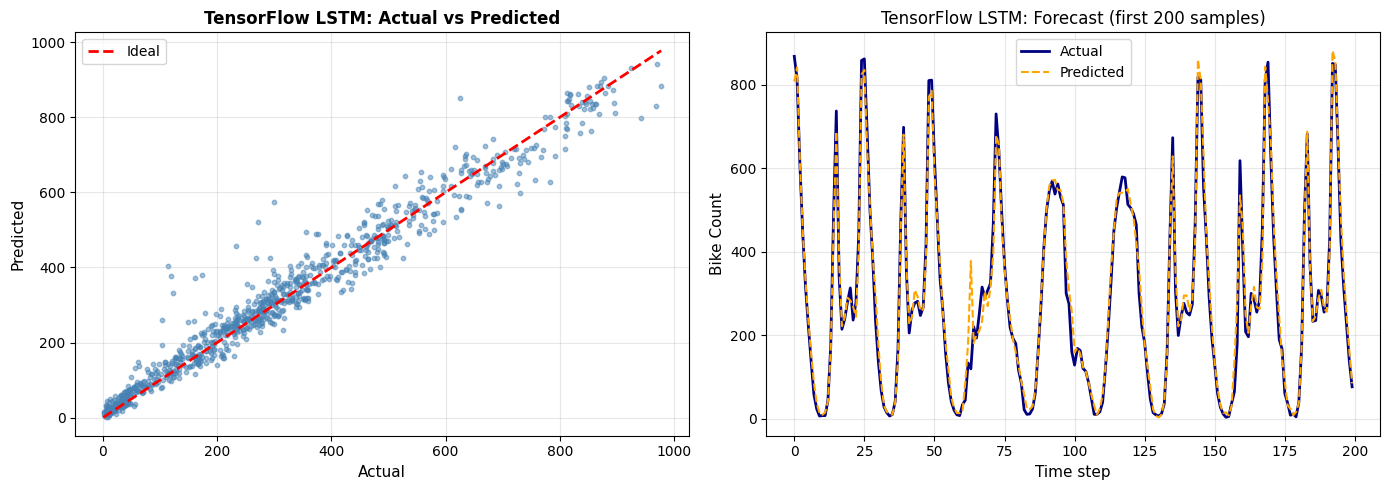

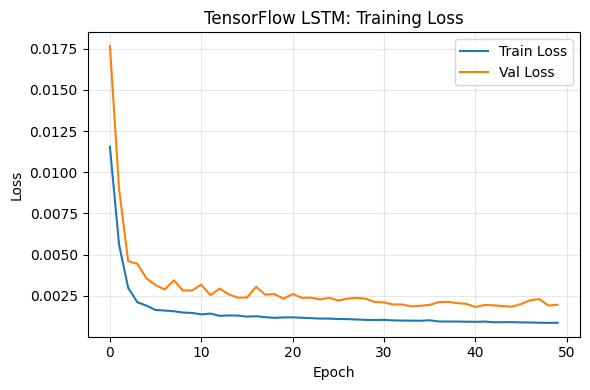

In [ ]:
y_pred_test_tf = tf_model.predict(X_test, verbose=0).flatten()

# Обратное преобразование
n_features = X_test.shape[-1]
y_test_inv_tf, y_pred_test_inv_tf = inverse_transform_target(
    y_test, y_pred_test_tf, scaler, target_idx, n_features
)

# Оценка и визуализация
metrics_tf = evaluate_and_plot(
    y_test, y_pred_test_tf,
    y_test_inv_tf, y_pred_test_inv_tf,
    model_name="TensorFlow LSTM",
    history=tf_history,
    sample_size=200
)

# GRU

## TensorFlow

In [ ]:
def build_tf_gru(input_shape, hidden_units=64):
    model = tf.keras.Sequential([
        tf.keras.layers.GRU(hidden_units, activation='tanh',
                            return_sequences=False, input_shape=input_shape),
        tf.keras.layers.Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='mse', metrics=['mae'])
    return model

def train_tf_gru(X_tr, y_tr, X_te, y_te, epochs=50, batch_size=32):
    print("Обучение TensorFlow GRU")
    input_shape = (X_tr.shape[1], X_tr.shape[2])
    model = build_tf_gru(input_shape, hidden_units=64)

    history = model.fit(X_tr, y_tr, epochs=epochs, batch_size=batch_size,
                        validation_data=(X_te, y_te), verbose=1)

    y_pred = model.predict(X_te).flatten()
    return model, history, y_pred

## Сравнение

 Обучение TensorFlow GRU...
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


434/434 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - loss: 0.0091 - mae: 0.0657 - val_loss: 0.0103 - val_mae: 0.0712
Epoch 2/50
434/434 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - loss: 0.0051 - mae: 0.0492 - val_loss: 0.0096 - val_mae: 0.0648
Epoch 3/50
434/434 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 0.0046 - mae: 0.0470 - val_loss: 0.0079 - val_mae: 0.0610
Epoch 4/50
434/434 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 0.0036 - mae: 0.0418 - val_loss: 0.0052 - val_mae: 0.0488
Epoch 5/50
434/434 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.0022 - mae: 0.0328 - val_loss: 0.0032 - val_mae: 0.0370
Epoch 6/50
434/434 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 0.0016 - mae: 0.0281 - val_loss: 0.0030 - val_mae: 0.0383
Epoch 7/50
434/434 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 0.0015 - mae: 0.0274 - val_loss: 0.0029 - val_mae: 0.0362
Epoch 8/50
434/434 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.0015 - mae: 0.0271 - val_loss: 0.0024 - val_mae: 0.0332
Epoch 9/50
434/434 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - 

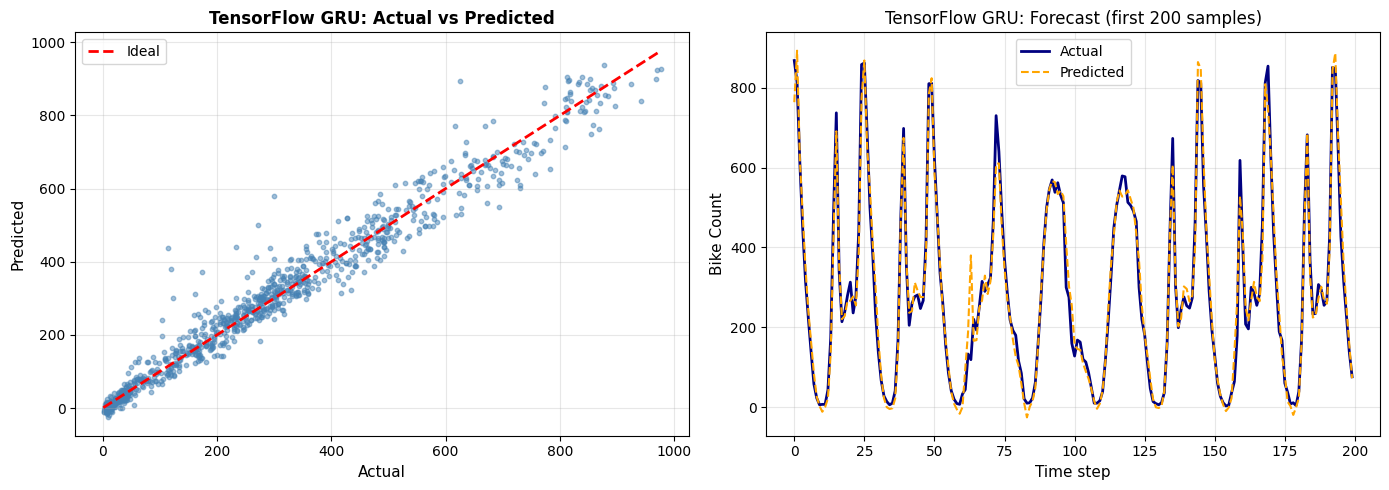

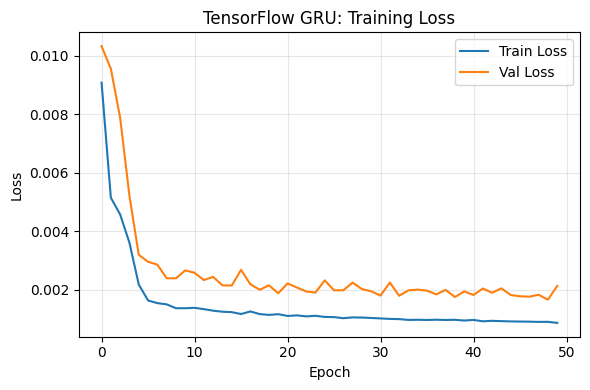

In [ ]:
# --- Обучение и оценка TF GRU ---
tf_gru_model, tf_gru_history, tf_gru_pred = train_tf_gru(X_train, y_train, X_test, y_test, epochs=50, batch_size=32)

y_test_inv_tf_gru, y_pred_test_inv_tf_gru = inverse_transform_target(
    y_test, tf_gru_pred, scaler, target_idx, n_features
)

metrics_tf_gru = evaluate_and_plot(
    y_test, tf_gru_pred,
    y_test_inv_tf_gru, y_pred_test_inv_tf_gru,
    model_name="TensorFlow GRU",
    history=tf_gru_history,
    sample_size=200
)


In [ ]:

print(f"{'='*60}")
print(f"{'Метрика':<15} {'TF GRU':<20} {'Manual GRU':<20}")
print("-" * 60)
print(f"{'MAE':<15} {metrics_tf_gru['MAE']:<20.2f} {metrics_manual_gru['MAE']:<20.2f}")
print(f"{'RMSE':<15} {metrics_tf_gru['RMSE']:<20.2f} {metrics_manual_gru['RMSE']:<20.2f}")
print(f"{'R² Score':<15} {metrics_tf_gru['R2']:<20.4f} {metrics_manual_gru['R2']:<20.4f}")

Метрика         TF GRU               Manual GRU          
------------------------------------------------------------
MAE             29.56                27.24               
RMSE            45.06                41.28               
R² Score        0.9583               0.9650              
